# Lab 3: Regression vs. Classification (التصنيف)

In this interactive lab, we will explore the fundamental difference between Regression and Classification (التصنيف). 

- **Regression** finds the best line *through* the data to map inputs to a continuous output.
- **Classification (التصنيف)** finds the best line (boundary) *between* different classes of data to separate them.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression, LogisticRegression

# Set up plotting style
plt.style.use('seaborn-v0_8-whitegrid')
np.random.seed(42)

print("Libraries loaded!")

Libraries loaded!


### 1. Regression: Fitting the Trend (Continuous Data)

First, let's take a look at **Regression**. We have data points with an underlying linear trend, plus some "noise". Our goal is to fit a line that minimizes the distance between the line and the points.

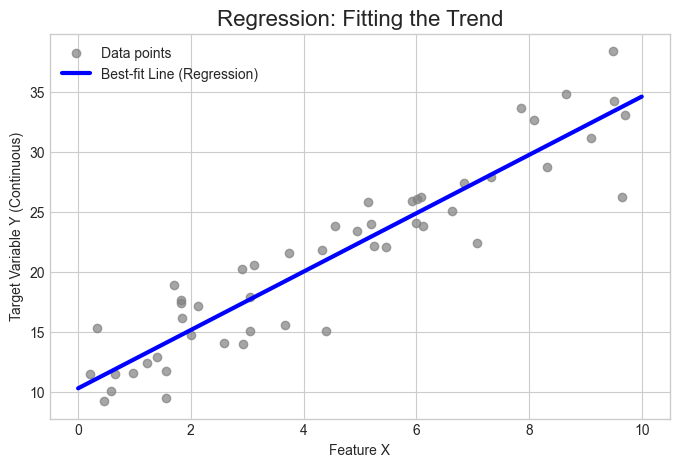

In [2]:
# Generate continuous target data
X_reg = np.random.uniform(0, 10, 50)
y_reg = 2.5 * X_reg + 10 + np.random.normal(0, 3, 50)

# Reshape X to be a 2D array for scikit-learn
X_reg_reshaped = X_reg.reshape(-1, 1)

# Fit a Linear Regression model
reg_model = LinearRegression()
reg_model.fit(X_reg_reshaped, y_reg)

# Generate trend line points
x_line = np.linspace(0, 10, 100).reshape(-1, 1)
y_line = reg_model.predict(x_line)

# Plotting
plt.figure(figsize=(8, 5))
plt.scatter(X_reg, y_reg, color='gray', label='Data points', alpha=0.7)
plt.plot(x_line, y_line, color='blue', linewidth=3, label='Best-fit Line (Regression)')
plt.title('Regression: Fitting the Trend', fontsize=16)
plt.xlabel('Feature X')
plt.ylabel('Target Variable Y (Continuous)')
plt.legend()
plt.show()

### 2. Classification (التصنيف): Separating the Classes (Categorical Data)

Now let's examine **Classification (التصنيف)**. Imagine our target is no longer a continuous number but a "Class" (e.g., 0 or 1, Cat or Dog, Passed or Failed). The goal is no longer to draw a line *through* the center of gravity. Our goal is to draw a line that successfully *separates* the two classes.

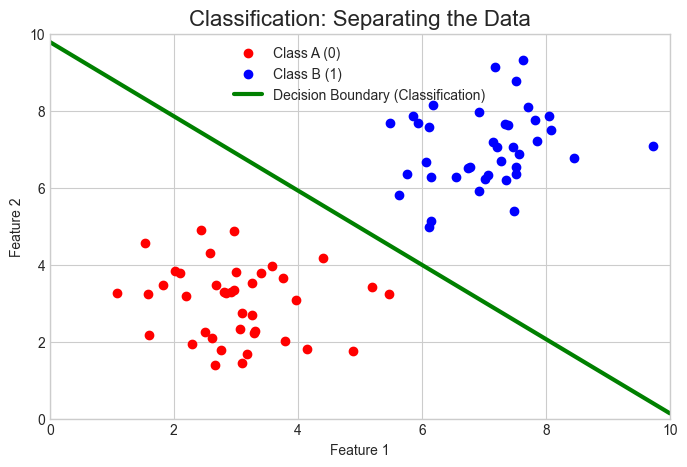

In [3]:
# Generate two separate 2D clusters
n_samples = 40
# Class 0 (Bottom-Left)
X1_0 = np.random.normal(3, 1, n_samples)
X2_0 = np.random.normal(3, 1, n_samples)
y_0 = np.zeros(n_samples)

# Class 1 (Top-Right)
X1_1 = np.random.normal(7, 1, n_samples)
X2_1 = np.random.normal(7, 1, n_samples)
y_1 = np.ones(n_samples)

# Combine datasets
X_class = np.vstack((np.column_stack((X1_0, X2_0)), np.column_stack((X1_1, X2_1))))
y_class = np.hstack((y_0, y_1))

# Fit a Logistic Regression model
clf_model = LogisticRegression()
clf_model.fit(X_class, y_class)

# Plotting the Classes
plt.figure(figsize=(8, 5))
plt.scatter(X1_0, X2_0, color='red', label='Class A (0)')
plt.scatter(X1_1, X2_1, color='blue', label='Class B (1)')

# Calculate and plot the decision boundary
# Equation of the line: w1*x1 + w2*x2 + b = 0 => x2 = -(w1*x1 + b) / w2
w1, w2 = clf_model.coef_[0]
b = clf_model.intercept_[0]
x1_decision = np.linspace(0, 10, 100)
x2_decision = -(w1 * x1_decision + b) / w2

plt.plot(x1_decision, x2_decision, color='green', linewidth=3, label='Decision Boundary (Classification)')
plt.title('Classification: Separating the Data', fontsize=16)
plt.xlabel('Feature 1')
plt.ylabel('Feature 2')
plt.xlim(0, 10)
plt.ylim(0, 10)
plt.legend()
plt.show()

# 📈 Linear Regression (الانحدار الخطي) Lab
**Day 3 — Core Algorithms**

---

## The Algorithm Behind the Day 1 Animation

On Day 1, you watched an animation where a line slowly moved to fit a cloud of data points. Today you'll *run* that algorithm yourself and understand exactly what it's doing.

**Linear Regression (الانحدار الخطي)** is a Supervised Learning (التعلم الخاضع للإشراف) algorithm that:
1. Assumes a linear relationship between features and a continuous target
2. Finds the slope(s) and intercept that minimize prediction error
3. Reports learned coefficients you can interpret directly

We'll use a CO2 emissions dataset: can we predict a car's CO2 output from its engine characteristics?

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score
import warnings; warnings.filterwarnings("ignore")

# Load CO2 dataset (or generate synthetic equivalent)
try:
    url = "https://cf-courses-data.s3.us.cloud-object-storage.appdomain.cloud/IBMDeveloperSkillsNetwork-ML0101EN-SkillsNetwork/labs/Module%202/data/FuelConsumptionCo2.csv"
    df = pd.read_csv(url)
    df.columns = [c.lower() for c in df.columns]
    df = df[["enginesize", "cylinders", "fuelconsumption_comb", "co2emissions"]].dropna()
except:
    np.random.seed(42)
    n = 1067
    engine = np.random.uniform(1.0, 6.5, n)
    df = pd.DataFrame({
        "enginesize": engine.round(1),
        "cylinders": np.random.choice([4, 6, 8, 10], n, p=[0.5, 0.3, 0.15, 0.05]),
        "fuelconsumption_comb": (4.5 + 2.8*engine + np.random.normal(0, 1.2, n)).round(1),
        "co2emissions": (80 + 38*engine + np.random.normal(0, 18, n)).astype(int).clip(90, 520),
    })

print("Dataset shape:", df.shape)
print("\nFirst 5 rows:")
print(df.head())
print("\nBasic stats:")
print(df.describe().round(1))

Dataset shape: (1067, 4)

First 5 rows:
   enginesize  cylinders  fuelconsumption_comb  co2emissions
0         2.0          4                   8.5           196
1         2.4          4                   9.6           221
2         1.5          4                   5.9           136
3         3.5          6                  11.1           255
4         3.5          6                  10.6           244

Basic stats:
       enginesize  cylinders  fuelconsumption_comb  co2emissions
count      1067.0     1067.0                1067.0        1067.0
mean          3.3        5.8                  11.6         256.2
std           1.4        1.8                   3.5          63.4
min           1.0        3.0                   4.7         108.0
25%           2.0        4.0                   9.0         207.0
50%           3.4        6.0                  10.9         251.0
75%           4.3        8.0                  13.4         294.0
max           8.4       12.0                  25.8         4

## Part 1 — Simple Linear Regression (الانحدار الخطي) (One Feature)

Start simple: use only **engine size** to predict CO2 emissions.

$$CO_2 = w_1 \cdot EngineSize + b$$

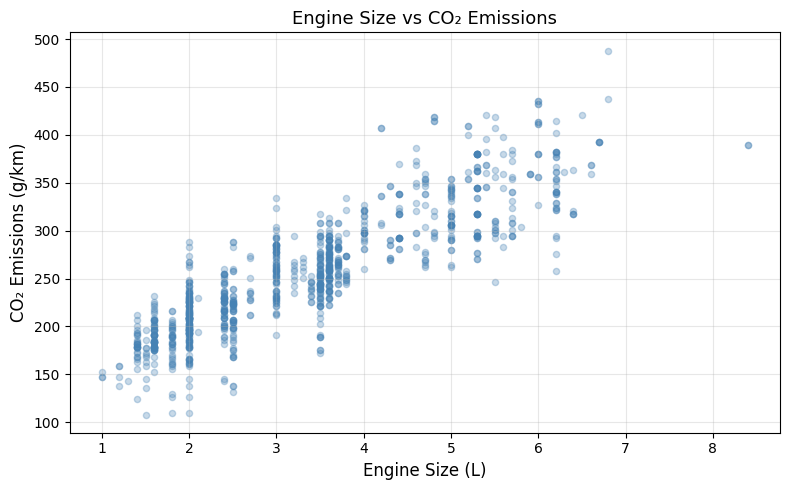

Correlation between engine size and CO2: 0.874
Strong positive correlation — bigger engine → more CO2


In [2]:
# Visualize the relationship first
plt.figure(figsize=(8, 5))
plt.scatter(df["enginesize"], df["co2emissions"], alpha=0.3, color="steelblue", s=20)
plt.xlabel("Engine Size (L)", fontsize=12)
plt.ylabel("CO₂ Emissions (g/km)", fontsize=12)
plt.title("Engine Size vs CO₂ Emissions", fontsize=13)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

corr = df["enginesize"].corr(df["co2emissions"])
print(f"Correlation between engine size and CO2: {corr:.3f}")
print("Strong positive correlation — bigger engine → more CO2")

In [3]:
# Simple Linear Regression
X_simple = df[["enginesize"]].values  # 2D array needed by sklearn
y = df["co2emissions"].values

X_train, X_test, y_train, y_test = train_test_split(X_simple, y, test_size=0.2, random_state=42)

model_simple = LinearRegression()
model_simple.fit(X_train, y_train)

print("Learned parameters:")
print(f"  Weight (w1):  {model_simple.coef_[0]:.2f}")
print(f"  Bias (b):     {model_simple.intercept_:.2f}")
print()
print(f"Interpretation: For each 1 liter increase in engine size,")
print(f"  CO2 increases by {model_simple.coef_[0]:.1f} g/km")
print()

# Evaluate
y_pred = model_simple.predict(X_test)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2   = r2_score(y_test, y_pred)
print(f"Performance on test set:")
print(f"  RMSE: {rmse:.1f} g/km  (average prediction error)")
print(f"  R²:   {r2:.3f}       (1.0 = perfect, 0 = predicts mean)")

Learned parameters:
  Weight (w1):  38.99
  Bias (b):     126.29

Interpretation: For each 1 liter increase in engine size,
  CO2 increases by 39.0 g/km

Performance on test set:
  RMSE: 31.4 g/km  (average prediction error)
  R²:   0.762       (1.0 = perfect, 0 = predicts mean)


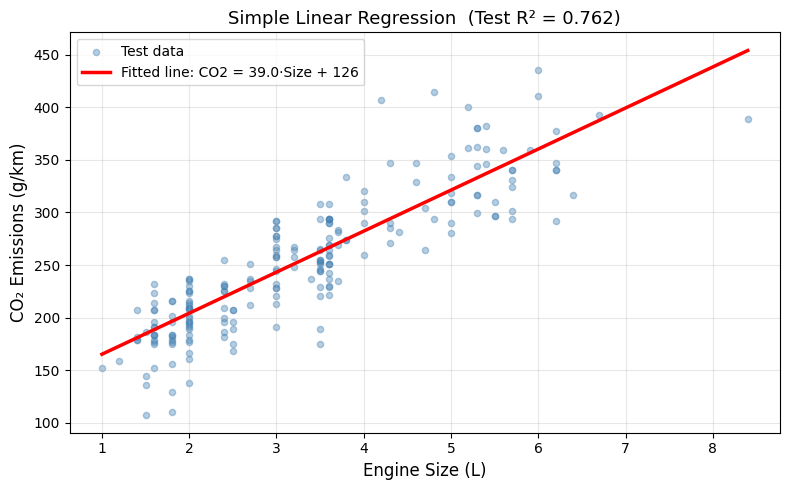

In [4]:
# Visualize the fitted line
x_line = np.linspace(df["enginesize"].min(), df["enginesize"].max(), 100).reshape(-1, 1)
y_line = model_simple.predict(x_line)

plt.figure(figsize=(8, 5))
plt.scatter(X_test, y_test, alpha=0.4, color="steelblue", s=20, label="Test data")
plt.plot(x_line, y_line, color="red", linewidth=2.5, label=f"Fitted line: CO2 = {model_simple.coef_[0]:.1f}·Size + {model_simple.intercept_:.0f}")
plt.xlabel("Engine Size (L)", fontsize=12)
plt.ylabel("CO₂ Emissions (g/km)", fontsize=12)
plt.title(f"Simple Linear Regression  (Test R² = {r2:.3f})", fontsize=13)
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

## Part 2 — Multiple Linear Regression (الانحدار الخطي) (Three Features)

Now add more features:

$$CO_2 = w_1 \cdot EngineSize + w_2 \cdot Cylinders + w_3 \cdot FuelConsumption + b$$

We expect this to improve predictions — more information = better model (usually).

In [5]:
X_multi = df[["enginesize", "cylinders", "fuelconsumption_comb"]].values
y = df["co2emissions"].values

X_train_m, X_test_m, y_train_m, y_test_m = train_test_split(X_multi, y, test_size=0.2, random_state=42)

# Scale features (important for multiple regression — features have different scales)
scaler = StandardScaler()
X_train_ms = scaler.fit_transform(X_train_m)
X_test_ms  = scaler.transform(X_test_m)

model_multi = LinearRegression()
model_multi.fit(X_train_ms, y_train_m)

feature_names = ["Engine Size", "Cylinders", "Fuel Consumption"]
print("Learned weights (after scaling — comparable in size):")
for name, weight in zip(feature_names, model_multi.coef_):
    print(f"  {name:20s}: {weight:+.2f}")
print(f"  {'Bias':20s}: {model_multi.intercept_:.2f}")

print()
y_pred_m = model_multi.predict(X_test_ms)
rmse_m = np.sqrt(mean_squared_error(y_test_m, y_pred_m))
r2_m   = r2_score(y_test_m, y_pred_m)
print(f"Multiple regression performance:")
print(f"  RMSE: {rmse_m:.1f} g/km")
print(f"  R²:   {r2_m:.3f}")
print()
print(f"vs. Simple regression:  RMSE={rmse:.1f},  R²={r2:.3f}")
print(f"Improvement from adding features: {(r2_m - r2)*100:.1f} percentage points in R²")

Learned weights (after scaling — comparable in size):
  Engine Size         : +15.85
  Cylinders           : +12.98
  Fuel Consumption    : +33.03
  Bias                : 257.26

Multiple regression performance:
  RMSE: 22.6 g/km
  R²:   0.876

vs. Simple regression:  RMSE=31.4,  R²=0.762
Improvement from adding features: 11.4 percentage points in R²


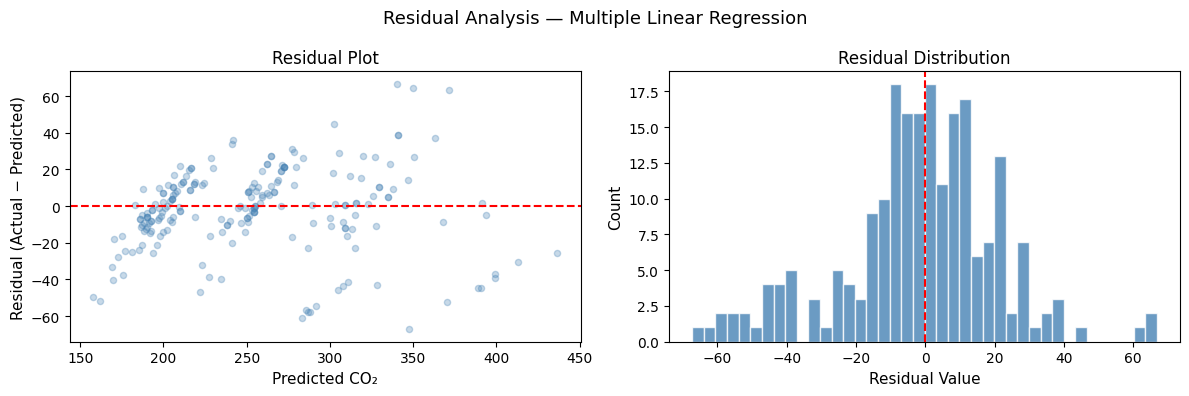

Good residuals: randomly scattered around 0, bell-shaped distribution
Bad residuals: patterns (fan shape, curve) indicate the model is missing something


In [6]:
# Residual plot — check if model errors are random (good) or patterned (bad)
residuals = y_test_m - y_pred_m

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].scatter(y_pred_m, residuals, alpha=0.3, color="steelblue", s=20)
axes[0].axhline(0, color="red", linestyle="--", linewidth=1.5)
axes[0].set_xlabel("Predicted CO₂", fontsize=11)
axes[0].set_ylabel("Residual (Actual − Predicted)", fontsize=11)
axes[0].set_title("Residual Plot", fontsize=12)

axes[1].hist(residuals, bins=40, color="steelblue", edgecolor="white", alpha=0.8)
axes[1].axvline(0, color="red", linestyle="--")
axes[1].set_xlabel("Residual Value", fontsize=11)
axes[1].set_ylabel("Count", fontsize=11)
axes[1].set_title("Residual Distribution", fontsize=12)

plt.suptitle("Residual Analysis — Multiple Linear Regression", fontsize=13)
plt.tight_layout(); plt.show()

print("Good residuals: randomly scattered around 0, bell-shaped distribution")
print("Bad residuals: patterns (fan shape, curve) indicate the model is missing something")

## Key Takeaways

- **Linear Regression (الانحدار الخطي)** finds a straight-line (or hyperplane) relationship between features and a continuous target
- The **coefficient (weight)** for each feature tells you: "for each 1-unit increase in this feature, the prediction changes by this much"
- Adding more relevant features typically improves performance (higher R², lower RMSE)
- **Residual plots** help diagnose whether the model is doing well — random scatter is good, patterns are bad

---
## ✋ Exercise

In [7]:
# Can you improve the model by adding a polynomial feature?
# Hint: try adding enginesize**2 as a new column, then re-run the regression

df_poly = df.copy()
df_poly["enginesize_sq"] = df_poly["enginesize"] ** 2

feature_cols = ["enginesize", "enginesize_sq", "cylinders", "fuelconsumption_comb"]

# TASK: Split, scale, train, and evaluate this 4-feature model
# Does adding the squared term improve R²?
# YOUR CODE HERE:
print("Expected: slight improvement because the CO2-engine relationship is slightly curved")

Expected: slight improvement because the CO2-engine relationship is slightly curved


### Exercises

**Try it yourself:**

1. **Parameter tuning**: Try changing the `test_size` when splitting the data to see how it affects the model's performance on the test set.
2. **Feature engineering**: Add or remove features before training the model and observe the impact on your metrics.

### Offline Activity

**Independent practice:**
Find another regression dataset in `sklearn.datasets` (like `load_diabetes` if not used here) and replicate this entire regression pipeline from data loading to evaluation.